# Task 1 — Binary Whole-Tumor Segmentation (U-Net baseline)

As a first step on BraTS2020 we tackle the simplest formulation of the segmentation problem: detecting
the **whole tumor** as a single foreground class.

* `0` = non-tumor (background + healthy brain)
* `1` = tumor — the union of BraTS labels **1 (NCR/NET) + 2 (ED) + 4 (ET)**

Because the raw BraTS labels are `{0, 1, 2, 4}`, the whole-tumor mask is simply `seg > 0`.

Whole tumor is the easiest of the BraTS targets — large and high-contrast on FLAIR — which makes it a
solid **baseline** for validating the whole pipeline end to end (data loading, normalization, the U-Net,
the training loop, and evaluation) before attempting to separate the individual tumor sub-regions.

## Design choices

A few deliberate choices in this baseline:

1. **Inputs** — FLAIR + T1ce, the two most informative modalities for tumor extent, resized to 128×128
   and **normalized per channel** (each modality scaled to [0, 1] independently, since FLAIR and T1ce
   sit on very different intensity scales).
2. **Mask** — binary `whole tumor = (seg > 0)`, resized with **nearest-neighbour** interpolation so the
   labels stay integer and small structures are preserved.
3. **Split** — a reproducible **patient-level** train/val/test split with a fixed seed, so no patient's
   slices leak across sets.
4. **Speed** — every MRI volume is read from disk **once** and its slices cached in RAM, so training is
   GPU-bound rather than I/O-bound and each epoch runs in seconds on a T4.
5. **Model / loss** — a BatchNorm U-Net with a single sigmoid output, trained with **BCE + soft Dice**,
   the standard pairing for imbalanced binary medical segmentation.

> **Runtime:** use the **GPU T4 ×2** accelerator (the older P100 is no longer supported by Kaggle's
> current PyTorch build). After the one-time preload the full run is well within the session limit.

# 1. Download and Unzip the Dataset

Upload your `kaggle.json` (API token) to the session first. If you instead added the dataset through
**+ Add Data**, skip these cells and point `TRAIN_DATASET_PATH` at the `/kaggle/input/...` location.

In [1]:
! pip install kaggle

In [2]:
! mkdir ~/.kaggle

In [3]:
! cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [4]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
! kaggle datasets download awsaf49/brats20-dataset-training-validation

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100%|███████████████████████████████████████| 4.16G/4.16G [00:15<00:00, 281MB/s]



In [6]:
import glob
print(len(glob.glob("/kaggle/working/**/BraTS20_Training_*", recursive=True)), "patient folders")

0 patient folders


In [7]:
! unzip -q brats20-dataset-training-validation.zip "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_0[0-5][0-9]/*"

# 2. Imports and Reproducibility

In [8]:
import os
import cv2
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import csv

# --- Reproducibility ---
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
TRAIN_DATASET_PATH = "/kaggle/working/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

# Slice selection and image size
VOLUME_SLICES   = 100   # number of axial slices used per case
VOLUME_START_AT = 22    # first slice index included
IMG_SIZE        = 128

# Task 1 is binary: 0 = non-tumor, 1 = whole tumor (BraTS labels 1 + 2 + 4)
SEGMENT_CLASSES = {0: 'NOT tumor', 1: 'WHOLE TUMOR'}

# 3. Explore the Whole-Tumor Mask

A quick look at one slice with its binary whole-tumor mask (the union of all tumor sub-regions).

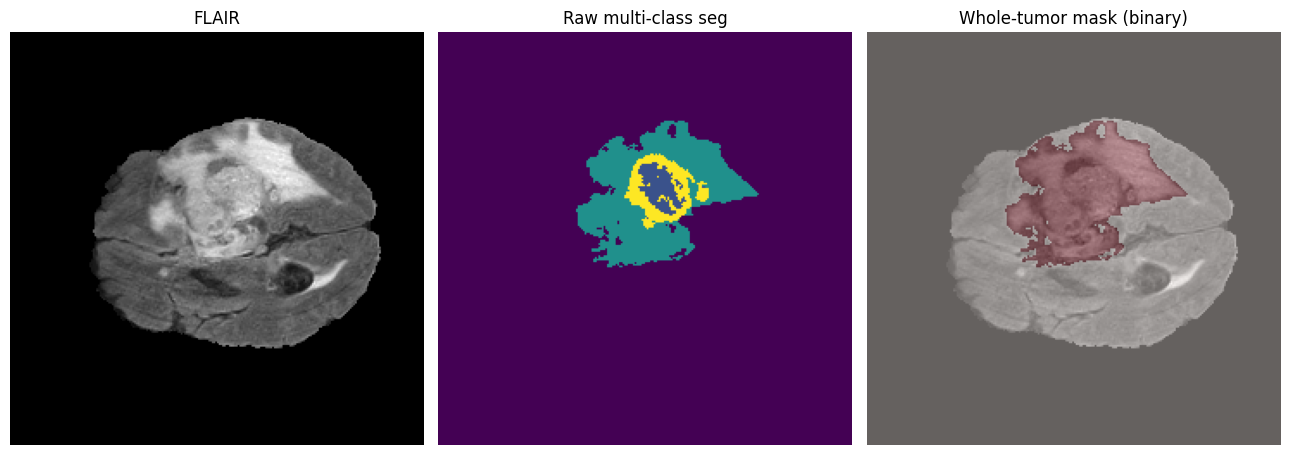

Case BraTS20_Training_001, slice 70: tumor pixels = 5017 / 57600


In [10]:
sample_case = sorted([f.name for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()])[0]
cp = os.path.join(TRAIN_DATASET_PATH, sample_case)
flair = nib.load(os.path.join(cp, f'{sample_case}_flair.nii')).get_fdata()
seg   = nib.load(os.path.join(cp, f'{sample_case}_seg.nii')).get_fdata()

s = 70  # slice index
wt = (seg[:, :, s] > 0).astype(np.uint8)  # whole tumor = labels 1 + 2 + 4

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].imshow(flair[:, :, s], cmap='gray'); ax[0].set_title('FLAIR'); ax[0].axis('off')
ax[1].imshow(seg[:, :, s]);               ax[1].set_title('Raw multi-class seg'); ax[1].axis('off')
ax[2].imshow(flair[:, :, s], cmap='gray')
ax[2].imshow(wt, cmap='Reds', alpha=0.4); ax[2].set_title('Whole-tumor mask (binary)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

print(f"Case {sample_case}, slice {s}: tumor pixels = {wt.sum()} / {wt.size}")

# 4. Split the Dataset

The split is over whole **patients** (case IDs), before slicing, with fixed `random_state` — so it is
reproducible and no patient's slices leak across train/val/test.

In [11]:
# Patient-level split. sorted() guarantees a deterministic, reproducible
# ordering BEFORE the split, so Task 1 and Task 2 get the IDENTICAL split.
train_and_val_directories = sorted(
    [f.path for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()]
)

def pathListIntoIds(dirList):
    return [p[p.rfind('/') + 1:] for p in dirList]

all_ids = pathListIntoIds(train_and_val_directories)

train_test_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=SEED)
train_ids, test_ids     = train_test_split(train_test_ids, test_size=0.15, random_state=SEED)

print(f"Train cases: {len(train_ids)}")
print(f"Val   cases: {len(val_ids)}")
print(f"Test  cases: {len(test_ids)}")

# --- Split verification (compare these against Task 2) ---
import hashlib
def _fingerprint(ids):
    return hashlib.md5(','.join(sorted(ids)).encode()).hexdigest()[:10]
print('\n--- SPLIT FINGERPRINT (must match Task 2) ---')
print(f"train: {_fingerprint(train_ids)}")
print(f"val  : {_fingerprint(val_ids)}")
print(f"test : {_fingerprint(test_ids)}")
print(f"test IDs: {sorted(test_ids)}")


Train cases: 39
Val   cases: 12
Test  cases: 8

--- SPLIT FINGERPRINT (must match Task 2) ---
train: 7dc9f2a3ec
val  : 01620d43a6
test : 90bcd58530
test IDs: ['BraTS20_Training_011', 'BraTS20_Training_015', 'BraTS20_Training_016', 'BraTS20_Training_030', 'BraTS20_Training_041', 'BraTS20_Training_044', 'BraTS20_Training_057', 'BraTS20_Training_059']


# 5. Preload Data into RAM (binary masks)

Each MRI volume is read from disk **once**, sliced, resized, and normalized, then cached in memory.
This removes the redundant disk I/O that otherwise dominates training time. The whole-tumor mask is
built here as `seg > 0`.

In [12]:
def preload_cases(list_IDs, desc=""):
    """Load each case once. Returns X (N,2,H,W) float32 and Y (N,H,W) uint8 binary WT masks."""
    X_all, Y_all = [], []
    for k, case_id in enumerate(list_IDs):
        cp = os.path.join(TRAIN_DATASET_PATH, case_id)
        flair = nib.load(os.path.join(cp, f'{case_id}_flair.nii')).get_fdata()
        t1ce  = nib.load(os.path.join(cp, f'{case_id}_t1ce.nii')).get_fdata()
        seg   = nib.load(os.path.join(cp, f'{case_id}_seg.nii')).get_fdata()

        for j in range(VOLUME_SLICES):
            sp = j + VOLUME_START_AT

            x = np.zeros((IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)
            x[:, :, 0] = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
            x[:, :, 1] = cv2.resize(t1ce[:, :, sp],  (IMG_SIZE, IMG_SIZE))

            # per-channel min-max normalization to [0, 1]
            for c in range(2):
                ch = x[:, :, c]
                mn, mx = ch.min(), ch.max()
                if mx > mn:
                    x[:, :, c] = (ch - mn) / (mx - mn)

            # whole-tumor binary mask = (seg > 0) == labels 1 + 2 + 4
            wt = (seg[:, :, sp] > 0).astype(np.uint8)
            wt = cv2.resize(wt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            X_all.append(x.transpose(2, 0, 1))  # (2, H, W)
            Y_all.append(wt)                    # (H, W) binary

        print(f"  {desc}: {k + 1}/{len(list_IDs)} cases loaded", end="\r")
    print()
    return np.stack(X_all), np.stack(Y_all)


class BinaryBrainDataset(Dataset):
    """Serves preloaded in-RAM slices for binary whole-tumor segmentation."""
    def __init__(self, X, Y):
        self.X = X  # (N, 2, H, W) float32
        self.Y = Y  # (N, H, W)    uint8 {0,1}

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])                       # (2, H, W)
        y = torch.from_numpy(self.Y[idx]).unsqueeze(0).float()  # (1, H, W)
        return x, y


print("Preloading data into RAM (one-time, a few minutes)...")
Xtr, Ytr = preload_cases(train_ids, "train")
Xva, Yva = preload_cases(val_ids,   "val")
Xte, Yte = preload_cases(test_ids,  "test")
print(f"Train slices: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")
print(f"Approx RAM used by cached arrays: "
      f"{(Xtr.nbytes + Xva.nbytes + Xte.nbytes) / 1e9:.2f} GB")

train_dataset = BinaryBrainDataset(Xtr, Ytr)
valid_dataset = BinaryBrainDataset(Xva, Yva)
test_dataset  = BinaryBrainDataset(Xte, Yte)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

Preloading data into RAM (one-time, a few minutes)...
  train: 39/39 cases loaded
  val: 12/12 cases loaded
  test: 8/8 cases loaded
Train slices: 3900 | Val: 1200 | Test: 800
Approx RAM used by cached arrays: 0.77 GB


# 6. Loss Function and Evaluation Metrics

**Loss:** binary cross-entropy + soft Dice. BCE alone is dominated by the large non-tumor area, so the
Dice term directly optimizes overlap on the tumor.

**Metrics (binary, thresholded at 0.5):** Dice, sensitivity (recall), specificity, precision.

*Note:* specificity will sit very high (~0.99) because non-tumor pixels dominate every slice — Dice and
sensitivity carry the real signal for this task.

In [13]:
class DiceBCELoss(nn.Module):
    """Combined BCE-with-logits + soft Dice loss for single-channel binary masks."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, logits, target):
        # logits, target: (B, 1, H, W); target in {0,1}
        bce_loss = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        p = probs.reshape(-1)
        t = target.reshape(-1)
        inter = (p * t).sum()
        dice = (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.bce_weight * bce_loss + self.dice_weight * (1 - dice)


def _binarize(y_pred, thr=0.5):
    return (y_pred > thr).float()

def dice_coef(y_true, y_pred, smooth=1e-6):
    """Hard Dice at threshold 0.5. y_pred = sigmoid probabilities."""
    p = _binarize(y_pred).reshape(-1)
    t = y_true.reshape(-1)
    inter = (p * t).sum()
    return (2 * inter + smooth) / (p.sum() + t.sum() + smooth)

def sensitivity(y_true, y_pred, eps=1e-7):
    """Recall = TP / (TP + FN)."""
    p = _binarize(y_pred); t = y_true
    tp = (p * t).sum()
    fn = ((1 - p) * t).sum()
    return tp / (tp + fn + eps)

def specificity(y_true, y_pred, eps=1e-7):
    """TN / (TN + FP)."""
    p = _binarize(y_pred); t = y_true
    tn = ((1 - p) * (1 - t)).sum()
    fp = (p * (1 - t)).sum()
    return tn / (tn + fp + eps)

def precision(y_true, y_pred, eps=1e-7):
    """TP / (TP + FP)."""
    p = _binarize(y_pred); t = y_true
    tp = (p * t).sum()
    fp = (p * (1 - t)).sum()
    return tp / (tp + fp + eps)

def compute_all_metrics(y_true, y_pred):
    """y_pred = sigmoid probabilities (B,1,H,W)."""
    return {
        'dice_coef':   dice_coef(y_true, y_pred).item(),
        'precision':   precision(y_true, y_pred).item(),
        'sensitivity': sensitivity(y_true, y_pred).item(),
        'specificity': specificity(y_true, y_pred).item(),
    }

# 7. The U-Net Model (single-channel output)

A standard U-Net encoder–decoder with BatchNorm in every convolutional block. For binary segmentation
it has a **single** output channel; the network returns raw logits, and sigmoid is applied in the loss
and at inference.

In [14]:
class UNet(nn.Module):
    """2D U-Net with BatchNorm. Output: (B, 1, H, W) raw logits for binary segmentation."""
    def __init__(self, in_channels=2, num_classes=1, dropout=0.5):
        super().__init__()

        def CBR(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(in_channels, 32)
        self.enc2 = CBR(32, 64)
        self.enc3 = CBR(64, 128)
        self.enc4 = CBR(128, 256)
        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = CBR(256, 512)
        self.dropout = nn.Dropout2d(p=dropout)

        self.up6 = nn.ConvTranspose2d(512, 256, 2, stride=2); self.dec6 = CBR(512, 256)
        self.up7 = nn.ConvTranspose2d(256, 128, 2, stride=2); self.dec7 = CBR(256, 128)
        self.up8 = nn.ConvTranspose2d(128, 64,  2, stride=2); self.dec8 = CBR(128, 64)
        self.up9 = nn.ConvTranspose2d(64,  32,  2, stride=2); self.dec9 = CBR(64,  32)

        self.out_conv = nn.Conv2d(32, num_classes, 1)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        bn = self.dropout(self.bottleneck(self.pool(c4)))
        d6 = self.dec6(torch.cat([c4, self.up6(bn)], 1))
        d7 = self.dec7(torch.cat([c3, self.up7(d6)], 1))
        d8 = self.dec8(torch.cat([c2, self.up8(d7)], 1))
        d9 = self.dec9(torch.cat([c1, self.up9(d8)], 1))
        return self.out_conv(d9)  # raw logits

# 8. Build the Model

In [15]:
model = UNet(in_channels=2, num_classes=1).to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = DiceBCELoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=3, min_lr=1e-6)

history = {k: [] for k in [
    'train_loss', 'val_loss', 'train_accuracy', 'val_accuracy',
    'train_dice_coef', 'val_dice_coef', 'train_precision', 'val_precision',
    'train_sensitivity', 'val_sensitivity', 'train_specificity', 'val_specificity',
    'learning_rate',
]}

def log_to_csv(epoch, train_metrics, val_metrics, filepath='training.log'):
    file_exists = os.path.isfile(filepath)
    with open(filepath, 'a', newline='') as f:
        fieldnames = (['epoch', 'lr']
                      + [f'train_{k}' for k in train_metrics]
                      + [f'val_{k}' for k in val_metrics])
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        row = {'epoch': epoch, 'lr': optimizer.param_groups[0]['lr']}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        writer.writerow(row)

Trainable parameters: 7,762,753


# 9. Training and Validation Helpers

In [16]:
def run_epoch(model, loader, criterion, optimizer, device, train):
    model.train() if train else model.eval()
    running_loss = 0.0
    sums = {'dice_coef': 0.0, 'precision': 0.0, 'sensitivity': 0.0, 'specificity': 0.0, 'accuracy': 0.0}
    n = 0

    torch.set_grad_enabled(train)
    for X, y_true in loader:
        X, y_true = X.to(device), y_true.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y_true)
        if train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            acc = (_binarize(probs) == y_true).float().mean().item()
            m = compute_all_metrics(y_true, probs)
            for k in ['dice_coef', 'precision', 'sensitivity', 'specificity']:
                sums[k] += m[k]
            sums['accuracy'] += acc
        n += 1
    torch.set_grad_enabled(True)

    avg_metrics = {k: v / max(n, 1) for k, v in sums.items()}
    return running_loss / max(n, 1), avg_metrics


def evaluate_model(model, loader, device):
    model.eval()
    sums = {'dice_coef': 0.0, 'precision': 0.0, 'sensitivity': 0.0, 'specificity': 0.0}
    n = 0
    with torch.no_grad():
        for X, y_true in loader:
            X, y_true = X.to(device), y_true.to(device)
            probs = torch.sigmoid(model(X))
            m = compute_all_metrics(y_true, probs)
            for k in sums:
                sums[k] += m[k]
            n += 1
    return {k: v / max(n, 1) for k, v in sums.items()}

# 10. Train and Save the Model

In [17]:
num_epochs = 30
best_val_dice = -1.0
best_model_path = 'best_model_task1.pth'

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print('-' * 50)

    train_loss, train_metrics = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    val_loss,   val_metrics   = run_epoch(model, valid_loader, criterion, optimizer, device, train=False)

    scheduler.step(val_metrics['dice_coef'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    for k in train_metrics:
        history[f'train_{k}'].append(train_metrics[k])
        history[f'val_{k}'].append(val_metrics[k])
    log_to_csv(epoch + 1, train_metrics, val_metrics)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Dice: {val_metrics['dice_coef']:.4f} | "
          f"Sens: {val_metrics['sensitivity']:.4f} | "
          f"Spec: {val_metrics['specificity']:.4f} | "
          f"Prec: {val_metrics['precision']:.4f}")

    if val_metrics['dice_coef'] > best_val_dice:
        best_val_dice = val_metrics['dice_coef']
        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                    'val_metrics': val_metrics}, best_model_path)
        print(f"  New best model saved (val Dice: {best_val_dice:.4f})")

print("Training completed!")
torch.save(model.state_dict(), 'final_model_task1.pth')

Starting training...

Epoch 1/30
--------------------------------------------------
Train Loss: 0.1440 | Val Loss: 0.2438
Val Dice: 0.6839 | Sens: 0.4924 | Spec: 0.9990 | Prec: 0.7538
  New best model saved (val Dice: 0.6839)

Epoch 2/30
--------------------------------------------------
Train Loss: 0.0821 | Val Loss: 0.2176
Val Dice: 0.6820 | Sens: 0.6092 | Spec: 0.9976 | Prec: 0.6687

Epoch 3/30
--------------------------------------------------
Train Loss: 0.0689 | Val Loss: 0.2022
Val Dice: 0.6863 | Sens: 0.6631 | Spec: 0.9961 | Prec: 0.6810
  New best model saved (val Dice: 0.6863)

Epoch 4/30
--------------------------------------------------
Train Loss: 0.0649 | Val Loss: 0.2113
Val Dice: 0.7041 | Sens: 0.5497 | Spec: 0.9991 | Prec: 0.7651
  New best model saved (val Dice: 0.7041)

Epoch 5/30
--------------------------------------------------
Train Loss: 0.0613 | Val Loss: 0.2084
Val Dice: 0.7068 | Sens: 0.5462 | Spec: 0.9992 | Prec: 0.7680
  New best model saved (val Dice: 0.70

# 11. Training History

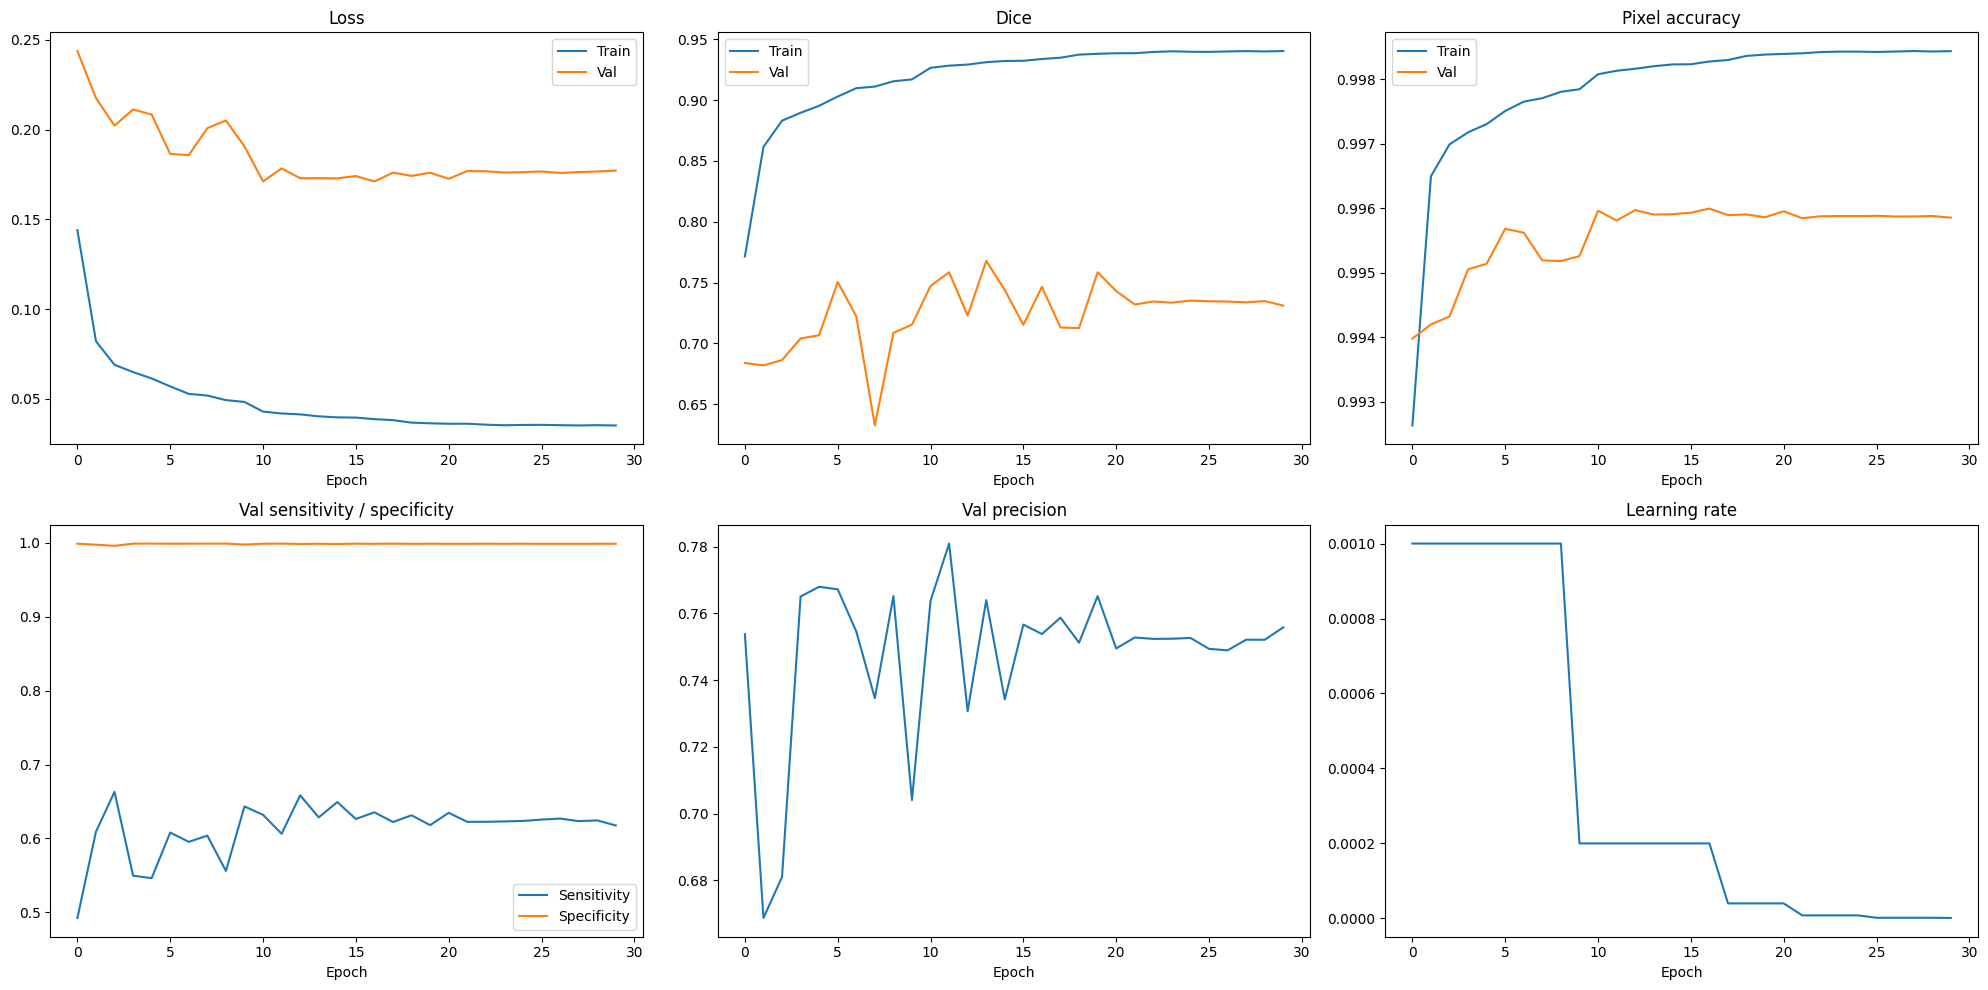

In [18]:
def plot_training_history(history):
    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    ax[0, 0].plot(history['train_loss'], label='Train'); ax[0, 0].plot(history['val_loss'], label='Val')
    ax[0, 0].set_title('Loss'); ax[0, 0].set_xlabel('Epoch'); ax[0, 0].legend()
    ax[0, 1].plot(history['train_dice_coef'], label='Train'); ax[0, 1].plot(history['val_dice_coef'], label='Val')
    ax[0, 1].set_title('Dice'); ax[0, 1].set_xlabel('Epoch'); ax[0, 1].legend()
    ax[0, 2].plot(history['train_accuracy'], label='Train'); ax[0, 2].plot(history['val_accuracy'], label='Val')
    ax[0, 2].set_title('Pixel accuracy'); ax[0, 2].set_xlabel('Epoch'); ax[0, 2].legend()
    ax[1, 0].plot(history['val_sensitivity'], label='Sensitivity'); ax[1, 0].plot(history['val_specificity'], label='Specificity')
    ax[1, 0].set_title('Val sensitivity / specificity'); ax[1, 0].set_xlabel('Epoch'); ax[1, 0].legend()
    ax[1, 1].plot(history['val_precision']); ax[1, 1].set_title('Val precision'); ax[1, 1].set_xlabel('Epoch')
    ax[1, 2].plot(history['learning_rate']); ax[1, 2].set_title('Learning rate'); ax[1, 2].set_xlabel('Epoch')
    plt.tight_layout(); plt.savefig('training_history_task1.png', dpi=150, bbox_inches='tight'); plt.show()

plot_training_history(history)

# 12. Load the Best Model

In [19]:
def load_model(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

best_model = load_model(model, best_model_path)
val_metrics = evaluate_model(best_model, valid_loader, device)
print("Validation performance (best model):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

Validation performance (best model):
  dice_coef: 0.7679
  precision: 0.7640
  sensitivity: 0.6285
  specificity: 0.9989


# 13. Predict and Visualize Whole-Tumor Segmentations

In [20]:
def predictByPath(case, model, device):
    """Predict whole-tumor probability volume for one case. Returns (VOLUME_SLICES, H, W)."""
    path = os.path.join(TRAIN_DATASET_PATH, f'BraTS20_Training_{case}')
    flair = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(path, f'BraTS20_Training_{case}_t1ce.nii')).get_fdata()

    X = np.zeros((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)
    for j in range(VOLUME_SLICES):
        sp = j + VOLUME_START_AT
        X[j, :, :, 0] = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(t1ce[:, :, sp],  (IMG_SIZE, IMG_SIZE))
    # per-channel, per-slice normalization to match training
    for j in range(VOLUME_SLICES):
        for c in range(2):
            ch = X[j, :, :, c]; mn, mx = ch.min(), ch.max()
            if mx > mn:
                X[j, :, :, c] = (ch - mn) / (mx - mn)

    X_tensor = torch.from_numpy(X).permute(0, 3, 1, 2).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_tensor))      # (S, 1, H, W)
    return probs.cpu().squeeze(1).numpy()           # (S, H, W)

In [21]:
def showPredictsById(case, model, device, start_slice=60, thr=0.5):
    path = os.path.join(TRAIN_DATASET_PATH, f'BraTS20_Training_{case}')
    gt    = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    flair = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()

    p = predictByPath(case, model, device)                 # (S, H, W) probabilities
    sp = start_slice + VOLUME_START_AT

    brain = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
    gt_wt = cv2.resize((gt[:, :, sp] > 0).astype(np.uint8), (IMG_SIZE, IMG_SIZE),
                       interpolation=cv2.INTER_NEAREST)
    pred_wt = (p[start_slice] > thr).astype(np.uint8)

    fig, ax = plt.subplots(1, 4, figsize=(18, 5))
    ax[0].imshow(brain, cmap='gray'); ax[0].set_title('FLAIR'); ax[0].axis('off')
    ax[1].imshow(brain, cmap='gray'); ax[1].imshow(gt_wt, cmap='Reds', alpha=0.4)
    ax[1].set_title('Ground-truth WT'); ax[1].axis('off')
    ax[2].imshow(brain, cmap='gray'); ax[2].imshow(p[start_slice], cmap='Reds', alpha=0.5)
    ax[2].set_title('Predicted probability'); ax[2].axis('off')
    ax[3].imshow(brain, cmap='gray'); ax[3].imshow(pred_wt, cmap='Reds', alpha=0.4)
    ax[3].set_title(f'Predicted WT (>{thr})'); ax[3].axis('off')
    plt.suptitle(f'Case {case}, slice {start_slice}')
    plt.tight_layout(); plt.show()

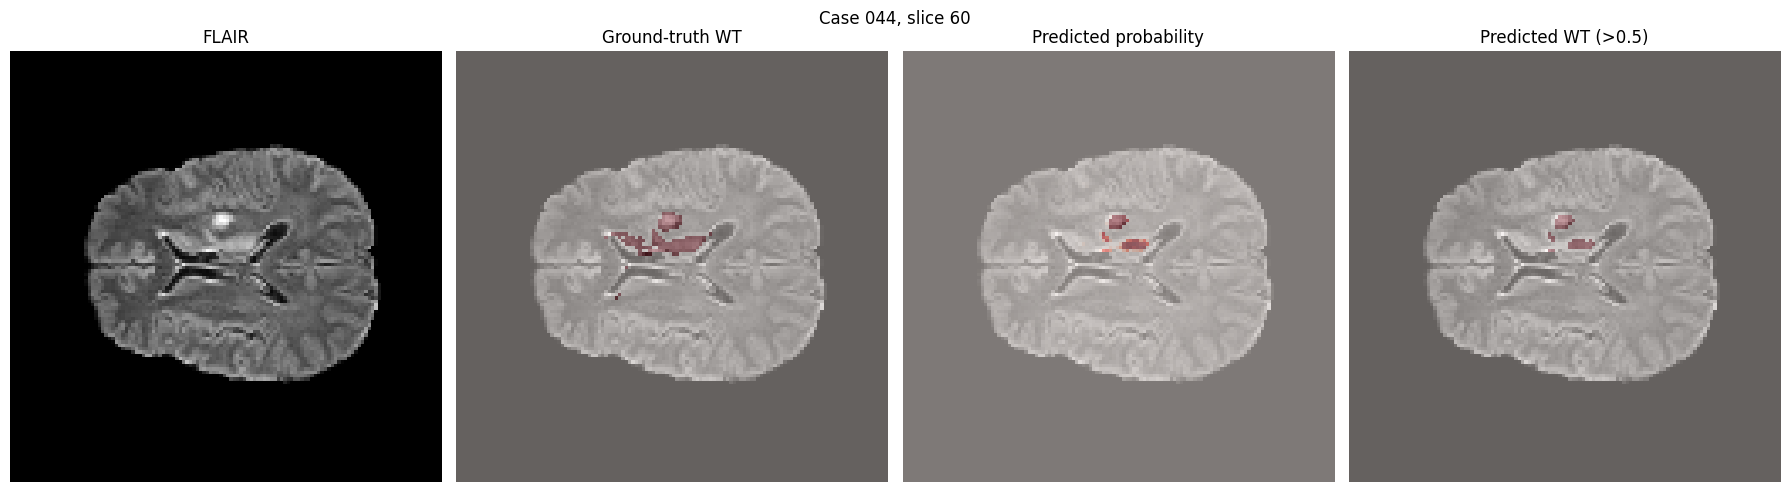

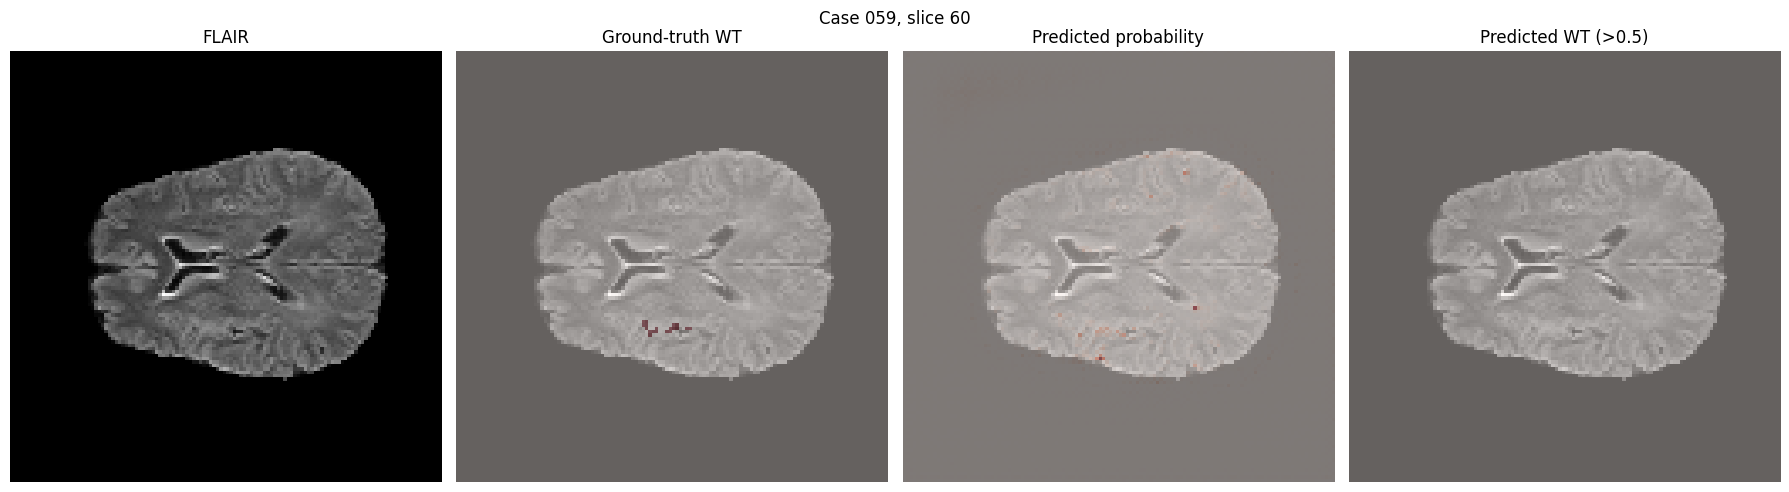

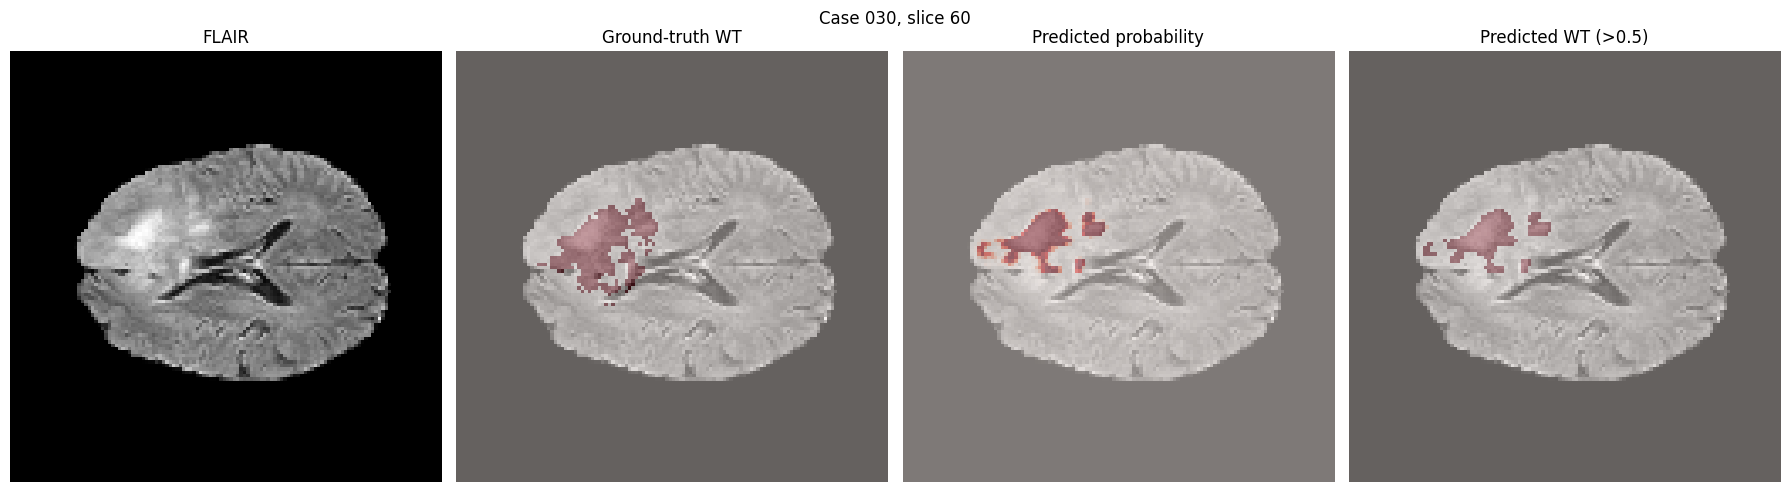

In [22]:
for cid in [test_ids[0][-3:], test_ids[1][-3:], test_ids[2][-3:]]:
    showPredictsById(case=cid, model=best_model, device=device)

# 14. Final Evaluation on the Test Set

In [23]:
best_model = load_model(model, best_model_path)
test_metrics = evaluate_model(best_model, test_loader, device)

print("=" * 40)
print("FINAL TEST-SET PERFORMANCE (whole tumor)")
print("=" * 40)
print(f"  Dice        : {test_metrics['dice_coef']:.4f}")
print(f"  Sensitivity : {test_metrics['sensitivity']:.4f}")
print(f"  Specificity : {test_metrics['specificity']:.4f}")
print(f"  Precision   : {test_metrics['precision']:.4f}")

FINAL TEST-SET PERFORMANCE (whole tumor)
  Dice        : 0.6673
  Sensitivity : 0.6467
  Specificity : 0.9988
  Precision   : 0.7314


# 15. Save Results & Figures to Disk (for download)

Everything written to `/kaggle/working/` can be downloaded after the run (right-hand
**Output** panel, or the **Output** tab of a committed version). This section saves the
Task 1 deliverables:

* `task1_results.json` / `task1_results.csv` — the test-set metrics (whole-tumor Dice,
  sensitivity, specificity, precision).
* `task1_metrics.png` — bar chart of those metrics.
* `task1_overlays.png` — qualitative FLAIR / ground-truth / prediction panels.

(The training-curve figure `training_history_task1.png` is already saved by
`plot_training_history` in Section 11.)

In [24]:
# --- Save the test-set metrics to JSON + CSV ---
# Uses `test_metrics` (computed in Section 14 on the best model) and `best_val_dice`.
import json, csv, os

OUTDIR = "/kaggle/working"
os.makedirs(OUTDIR, exist_ok=True)

results = {
    "task": "task1_binary_whole_tumor_segmentation",
    "best_val_dice": float(best_val_dice),
    "test": {k: float(v) for k, v in test_metrics.items()},
}
with open(os.path.join(OUTDIR, "task1_results.json"), "w") as f:
    json.dump(results, f, indent=2)

# flat one-row CSV for easy spreadsheet import
flat = {"best_val_dice": float(best_val_dice)}
flat.update({f"test_{k}": float(v) for k, v in test_metrics.items()})
with open(os.path.join(OUTDIR, "task1_results.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(flat.keys()))
    w.writeheader()
    w.writerow(flat)

print("Saved task1_results.json and task1_results.csv")
print(json.dumps(results, indent=2))

Saved task1_results.json and task1_results.csv
{
  "task": "task1_binary_whole_tumor_segmentation",
  "best_val_dice": 0.7679002006960932,
  "test": {
    "dice_coef": 0.6673041566090007,
    "precision": 0.7314484167098999,
    "sensitivity": 0.6467363548278808,
    "specificity": 0.9987758016586303
  }
}


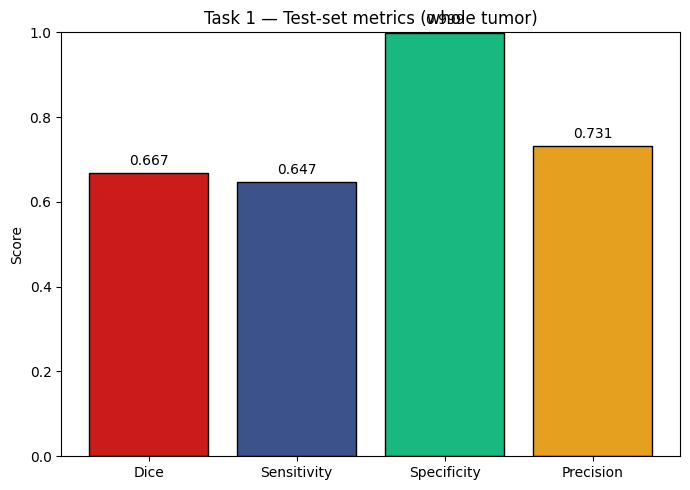

Saved task1_metrics.png


In [25]:
# --- Bar chart of the whole-tumor test metrics ---
import matplotlib.pyplot as plt

labels = ["Dice", "Sensitivity", "Specificity", "Precision"]
vals   = [test_metrics["dice_coef"], test_metrics["sensitivity"],
          test_metrics["specificity"], test_metrics["precision"]]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, vals, color=["#cc1b1b", "#3b528b", "#18b880", "#e6a020"], edgecolor="black")
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Task 1 — Test-set metrics (whole tumor)")
for r, v in zip(bars, vals):
    ax.text(r.get_x() + r.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("/kaggle/working/task1_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved task1_metrics.png")

### Qualitative overlay panels

For each chosen test slice we show, side by side, the **FLAIR input**, the **ground-truth**
whole-tumor mask, and the **model prediction** (sigmoid thresholded at 0.5), with the tumour
region shaded in red. Slices are picked deterministically and spread across the test set,
restricted to slices that actually contain tumour so the panels are informative rather than
mostly background.

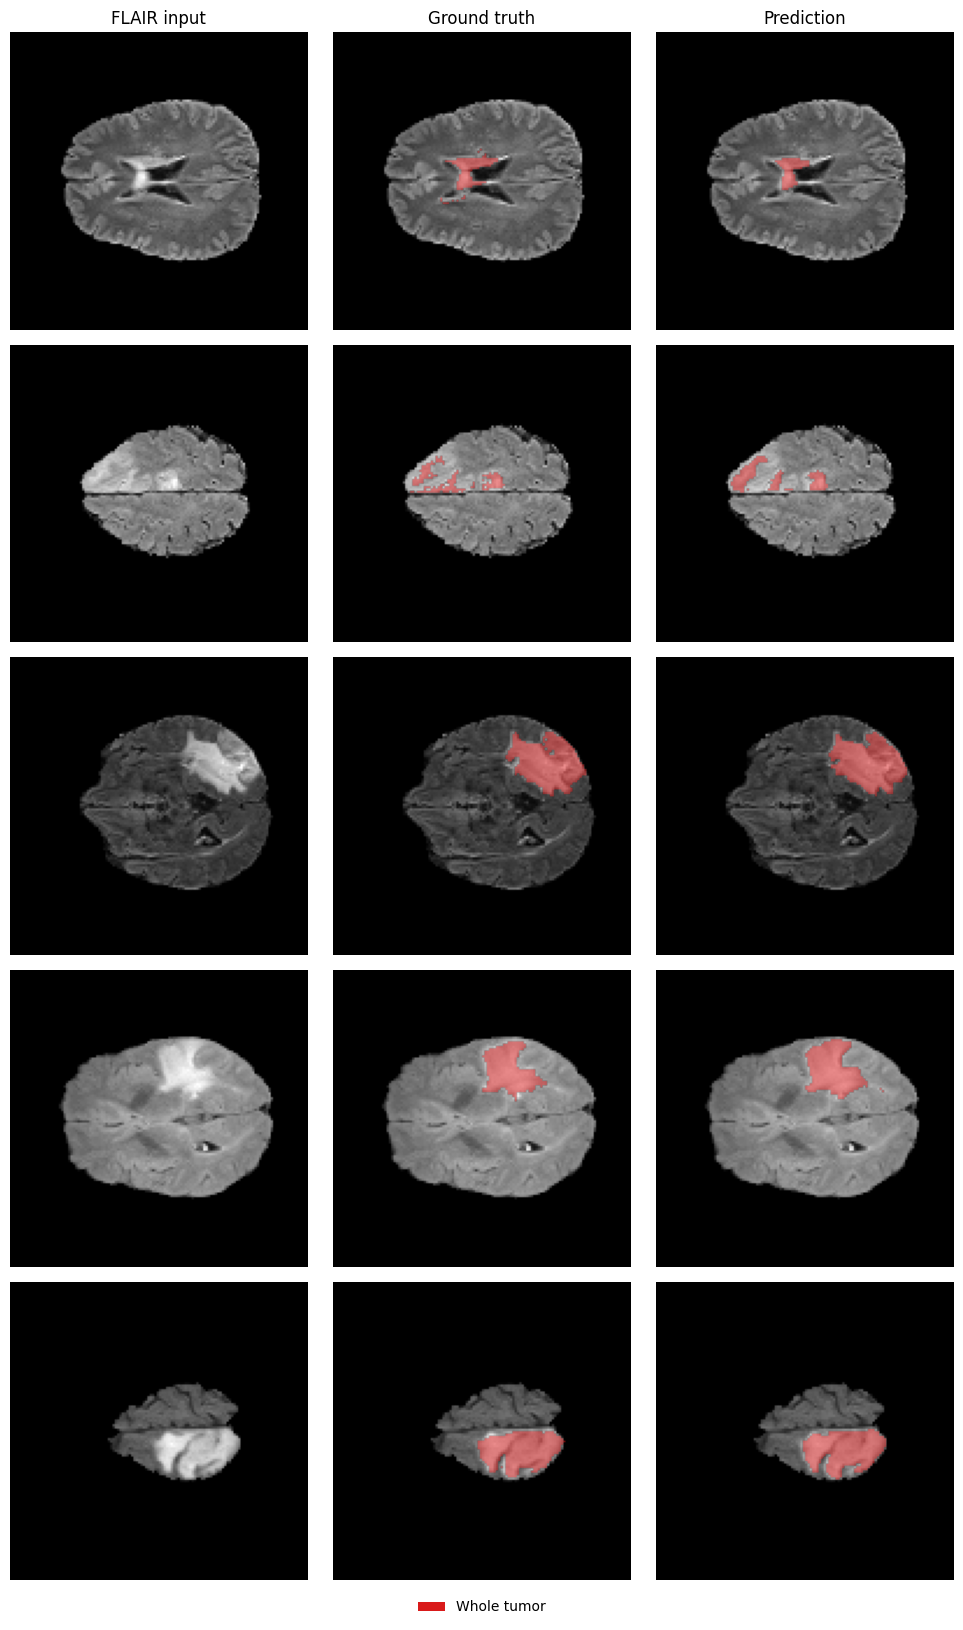

Saved task1_overlays.png  (slices [67, 293, 439, 646, 799])


In [26]:
# --- Qualitative FLAIR / Ground-truth / Prediction overlay panels ---
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TUMOR_COLOR = (0.85, 0.10, 0.10)  # red for the whole-tumor mask

def mask_to_rgba(mask, alpha=0.50):
    """(H,W) binary mask {0,1} -> (H,W,4) RGBA; background transparent."""
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    sel = mask == 1
    rgba[sel, 0], rgba[sel, 1], rgba[sel, 2], rgba[sel, 3] = (*TUMOR_COLOR, alpha)
    return rgba

# Pick a FIXED, reproducible set of tumour-containing test slices, spread across the set.
N_PANELS = 5
tumor_pixels = (Yte > 0).reshape(len(Yte), -1).sum(axis=1)
cand = np.where(tumor_pixels > 150)[0]
if len(cand) >= N_PANELS:
    chosen = cand[np.linspace(0, len(cand) - 1, N_PANELS).astype(int)]
else:
    chosen = np.argsort(tumor_pixels)[::-1][:N_PANELS]

# Predict on the chosen slices with the best model (single-channel sigmoid, threshold 0.5).
best_model.eval()
with torch.no_grad():
    xb = torch.from_numpy(Xte[chosen]).to(device)            # (N, 2, H, W)
    prob = torch.sigmoid(best_model(xb))                     # (N, 1, H, W)
    pred_mask = (prob > 0.5).float().squeeze(1).cpu().numpy()  # (N, H, W)

fig, axes = plt.subplots(N_PANELS, 3, figsize=(10, 3.2 * N_PANELS))
for row, idx in enumerate(chosen):
    flair = Xte[idx, 0]          # FLAIR channel
    for col in range(3):
        axes[row, col].imshow(flair, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 1].imshow(mask_to_rgba(Yte[idx]))        # ground truth
    axes[row, 2].imshow(mask_to_rgba(pred_mask[row]))  # prediction

axes[0, 0].set_title("FLAIR input")
axes[0, 1].set_title("Ground truth")
axes[0, 2].set_title("Prediction")

fig.legend(handles=[Patch(facecolor=TUMOR_COLOR, label="Whole tumor")],
           loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("/kaggle/working/task1_overlays.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved task1_overlays.png  (slices {chosen.tolist()})")

# 15. Conclusion

This baseline performs **binary whole-tumor segmentation** (BraTS labels 1 + 2 + 4 vs. background) with
a BatchNorm U-Net trained on FLAIR + T1ce slices. It establishes a working end-to-end pipeline —
preprocessing, normalization, training, and evaluation — and gives a reference score on the easiest
BraTS target.

**Future work / next steps**
* **Multi-class sub-region segmentation:** split the single foreground class into the individual tumor
  sub-regions — necrotic/non-enhancing core, edema, and enhancing tumor. This is the harder, more
  clinically detailed problem and the natural follow-up to this baseline.
* Train on more cases (widen the unzip glob beyond the first ~60 patients).
* Add light data augmentation (flips, small rotations) for a modest robustness gain.